In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trousers_ts = pd.read_csv('../data/processed/trousers_daily_sales.csv', parse_dates=['date'])

# Focusing on skinny/slim fit trousers only
skinny = trousers_ts[trousers_ts['fit_category'] == 'skinny_slim'].copy()
skinny = skinny.set_index('date')['units_sold']
skinny = skinny.asfreq('D')  # ensure every single day is represented, even if 0

print(skinny.shape)
skinny.head()

(734,)


date
2018-09-20    5007
2018-09-21    4795
2018-09-22    1838
2018-09-23    6752
2018-09-24    4933
Freq: D, Name: units_sold, dtype: int64

In [2]:
naive_forecast = skinny.shift(1)

comparison = pd.DataFrame({
    'actual': skinny,
    'naive_forecast': naive_forecast
})
comparison.head(10)

,actual,naive_forecast
date,,
2018-09-20,5007,NaN
2018-09-21,4795,5007.0
2018-09-22,1838,4795.0
2018-09-23,6752,1838.0
2018-09-24,4933,6752.0
2018-09-25,4319,4933.0
2018-09-26,4666,4319.0
2018-09-27,4134,4666.0
2018-09-28,5837,4134.0


In [3]:
comparison_clean = comparison.dropna()

errors = comparison_clean['actual'] - comparison_clean['naive_forecast']
mae = errors.abs().mean()

print(f"Naive baseline MAE: {mae:.1f} units")
print(f"Average daily sales: {comparison_clean['actual'].mean():.1f} units")

Naive baseline MAE: 541.5 units
Average daily sales: 2773.4 units


In [4]:
moving_avg_forecast = skinny.shift(1).rolling(window=7).mean()

comparison['moving_avg_forecast'] = moving_avg_forecast
comparison_clean = comparison.dropna()

mae_naive = (comparison_clean['actual'] - comparison_clean['naive_forecast']).abs().mean()
mae_moving_avg = (comparison_clean['actual'] - comparison_clean['moving_avg_forecast']).abs().mean()

print(f"Naive baseline MAE:       {mae_naive:.1f} units")
print(f"7-day moving avg MAE:     {mae_moving_avg:.1f} units")

Naive baseline MAE:       531.0 units
7-day moving avg MAE:     595.6 units


In [5]:
from sklearn.linear_model import LinearRegression

skinny_df = skinny.reset_index()
skinny_df.columns = ['date', 'units_sold']
skinny_df['day_number'] = (skinny_df['date'] - skinny_df['date'].min()).dt.days

skinny_df.head()

,date,units_sold,day_number
0,2018-09-20,5007,0
1,2018-09-21,4795,1
2,2018-09-22,1838,2
3,2018-09-23,6752,3
4,2018-09-24,4933,4


In [6]:
split_point = int(len(skinny_df) * 0.8)

train = skinny_df.iloc[:split_point]
test = skinny_df.iloc[split_point:]

print(f"Train: {train['date'].min()} to {train['date'].max()} ({len(train)} days)")
print(f"Test:  {test['date'].min()} to {test['date'].max()} ({len(test)} days)")

Train: 2018-09-20 00:00:00 to 2020-04-28 00:00:00 (587 days)
Test:  2020-04-29 00:00:00 to 2020-09-22 00:00:00 (147 days)


In [7]:
model = LinearRegression()
model.fit(train[['day_number']], train['units_sold'])

print(f"Slope (change per day): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Slope (change per day): -2.58
Intercept: 3719.96


In [8]:
test_predictions = model.predict(test[['day_number']])

mae_linear = np.abs(test['units_sold'].values - test_predictions).mean()

print(f"Naive baseline MAE (for reference): 531.0 units")
print(f"Linear trend model MAE:             {mae_linear:.1f} units")

Naive baseline MAE (for reference): 531.0 units
Linear trend model MAE:             460.2 units


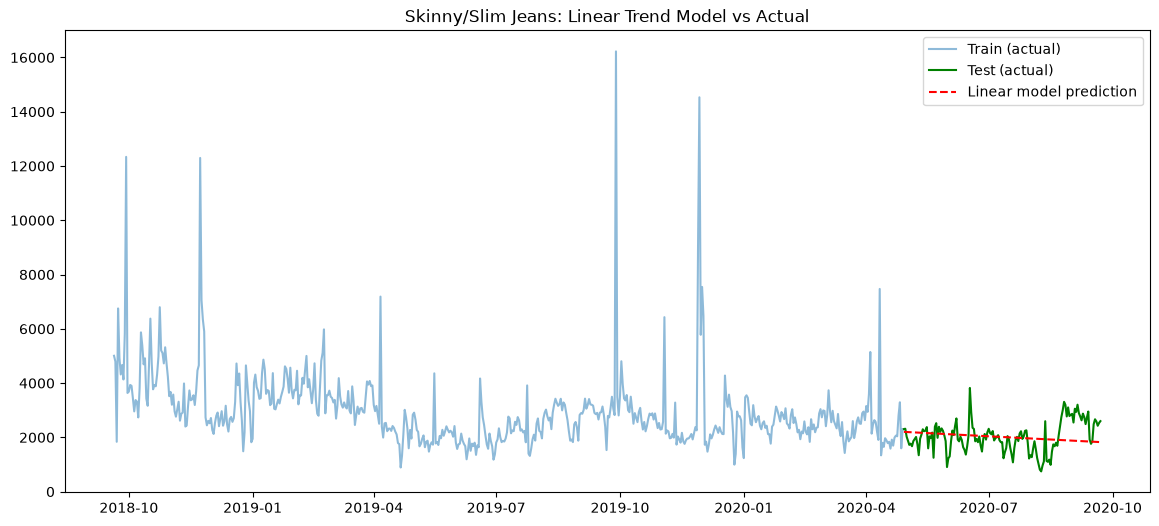

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train['date'], train['units_sold'], label='Train (actual)', alpha=0.5)
ax.plot(test['date'], test['units_sold'], label='Test (actual)', color='green')
ax.plot(test['date'], test_predictions, label='Linear model prediction', color='red', linestyle='--')
ax.legend()
ax.set_title('Skinny/Slim Jeans: Linear Trend Model vs Actual')
plt.show()

In [10]:
x = train['day_number']
y = train['units_sold']

x_mean = x.mean()
y_mean = y.mean()

numerator = ((x - x_mean) * (y - y_mean)).sum()
denominator = ((x - x_mean) ** 2).sum()
manual_slope = numerator / denominator

manual_intercept = y_mean - manual_slope * x_mean

print(f"Manual slope: {manual_slope:.2f}")
print(f"Manual intercept: {manual_intercept:.2f}")
print(f"(Compare to sklearn: slope={model.coef_[0]:.2f}, intercept={model.intercept_:.2f})")

Manual slope: -2.58
Manual intercept: 3719.96
(Compare to sklearn: slope=-2.58, intercept=3719.96)


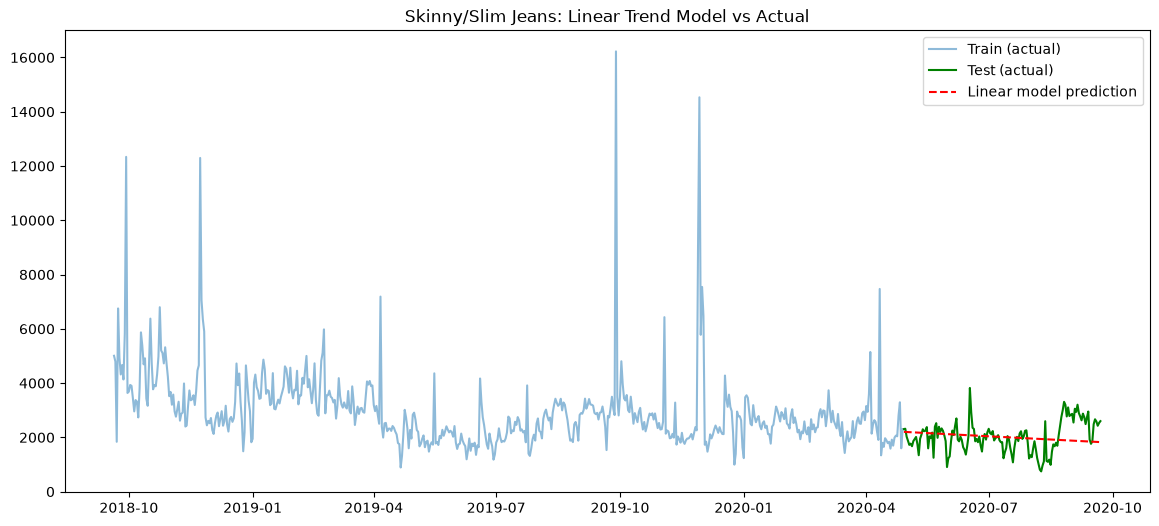

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train['date'], train['units_sold'], label='Train (actual)', alpha=0.5)
ax.plot(test['date'], test['units_sold'], label='Test (actual)', color='green')
ax.plot(test['date'], test_predictions, label='Linear model prediction', color='red', linestyle='--')
ax.legend()
ax.set_title('Skinny/Slim Jeans: Linear Trend Model vs Actual')
plt.show()

In [14]:
def evaluate_category(ts_data, category_col, category_name, target_col='units_sold'):
    series = ts_data[ts_data[category_col] == category_name].copy()
    series = series.set_index('date')[target_col].asfreq('D')
    
    df = series.reset_index()
    df.columns = ['date', target_col]
    df['day_number'] = (df['date'] - df['date'].min()).dt.days
    df['naive_forecast'] = df[target_col].shift(1)  # build naive forecast as a column here instead
    
    split_point = int(len(df) * 0.8)
    train = df.iloc[:split_point]
    test = df.iloc[split_point:]
    
    # Naive baseline - now using matching integer indexes, no mismatch
    mae_naive = np.abs(test[target_col].values - test['naive_forecast'].values).mean()
    
    # Linear regression
    model = LinearRegression()
    model.fit(train[['day_number']], train[target_col])
    test_pred = model.predict(test[['day_number']])
    mae_linear = np.abs(test[target_col].values - test_pred).mean()
    
    return {
        'category': category_name,
        'mae_naive': round(mae_naive, 1),
        'mae_linear': round(mae_linear, 1),
        'slope': round(model.coef_[0], 3),
        'improvement_pct': round((mae_naive - mae_linear) / mae_naive * 100, 1)
    }

In [15]:
results = []
for category in trousers_ts['fit_category'].unique():
    result = evaluate_category(trousers_ts, 'fit_category', category)
    results.append(result)

results_df = pd.DataFrame(results)
results_df

,category,mae_naive,mae_linear,slope,improvement_pct
0,tapered,249.0,323.4,0.525,-29.8
1,straight,164.9,259.9,-0.030,-57.6
2,skinny_slim,280.5,460.2,-2.583,-64.1
3,wide_relaxed,44.7,87.2,-0.322,-95.0
4,regular,16.7,133.6,0.285,-702.1


In [16]:
def evaluate_category_precovid(ts_data, category_col, category_name, target_col='units_sold'):
    series = ts_data[ts_data[category_col] == category_name].copy()
    series = series.set_index('date')[target_col].asfreq('D')
    
    df = series.reset_index()
    df.columns = ['date', target_col]
    df['day_number'] = (df['date'] - df['date'].min()).dt.days
    df['naive_forecast'] = df[target_col].shift(1)
    
    # Train on everything before Nov 2019, test on Nov 2019 - Feb 2020 (pre-COVID window)
    train = df[df['date'] < '2019-11-01']
    test = df[(df['date'] >= '2019-11-01') & (df['date'] < '2020-02-01')]
    
    mae_naive = np.abs(test[target_col].values - test['naive_forecast'].values).mean()
    
    model = LinearRegression()
    model.fit(train[['day_number']], train[target_col])
    test_pred = model.predict(test[['day_number']])
    mae_linear = np.abs(test[target_col].values - test_pred).mean()
    
    return {
        'category': category_name,
        'mae_naive': round(mae_naive, 1),
        'mae_linear': round(mae_linear, 1),
        'improvement_pct': round((mae_naive - mae_linear) / mae_naive * 100, 1)
    }

In [17]:
precovid_results = []
for category in trousers_ts['fit_category'].unique():
    result = evaluate_category_precovid(trousers_ts, 'fit_category', category)
    precovid_results.append(result)

precovid_results_df = pd.DataFrame(precovid_results)
precovid_results_df

,category,mae_naive,mae_linear,improvement_pct
0,tapered,255.5,631.7,-147.2
1,straight,105.8,579.2,-447.4
2,skinny_slim,704.6,923.8,-31.1
3,wide_relaxed,32.1,218.4,-580.7
4,regular,56.8,55.7,1.9


In [18]:
from sklearn.metrics import mean_absolute_error

skinny = trousers_ts[trousers_ts['fit_category'] == 'skinny_slim'].copy()
skinny = skinny.set_index('date')['units_sold'].asfreq('D')
skinny_df = skinny.reset_index()
skinny_df.columns = ['date', 'units_sold']

# Calendar features
skinny_df['day_of_week'] = skinny_df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
skinny_df['month'] = skinny_df['date'].dt.month              # 1-12
skinny_df['day_of_year'] = skinny_df['date'].dt.dayofyear    # 1-365

# Lag features - what were sales N days ago?
skinny_df['lag_1'] = skinny_df['units_sold'].shift(1)        # yesterday
skinny_df['lag_7'] = skinny_df['units_sold'].shift(7)        # same day last week
skinny_df['rolling_7'] = skinny_df['units_sold'].shift(1).rolling(7).mean()  # last 7-day avg

skinny_df = skinny_df.dropna()  # drop early rows that don't have full lag history
skinny_df.head()

,date,units_sold,day_of_week,month,day_of_year,lag_1,lag_7,rolling_7
7,2018-09-27,4134,3,9,270,4666.0,5007.0,4615.714286
8,2018-09-28,5837,4,9,271,4134.0,4795.0,4491.000000
9,2018-09-29,12337,5,9,272,5837.0,1838.0,4639.857143
10,2018-09-30,3637,6,9,273,12337.0,6752.0,6139.714286
11,2018-10-01,3688,0,10,274,3637.0,4933.0,5694.714286


In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

feature_cols = ['day_of_week', 'month', 'day_of_year', 'lag_1', 'lag_7', 'rolling_7']

split_point = int(len(skinny_df) * 0.8)
train = skinny_df.iloc[:split_point]
test = skinny_df.iloc[split_point:]

model_gb = HistGradientBoostingRegressor(max_iter=100, max_depth=4, learning_rate=0.1, random_state=42)
model_gb.fit(train[feature_cols], train['units_sold'])

test_pred = model_gb.predict(test[feature_cols])

mae_gb = mean_absolute_error(test['units_sold'], test_pred)

naive_pred = test['lag_1']
mae_naive = mean_absolute_error(test['units_sold'], naive_pred)

print(f"Naive baseline MAE:      {mae_naive:.1f}")
print(f"Gradient Boosting MAE:   {mae_gb:.1f}")

Naive baseline MAE:      282.4
Gradient Boosting MAE:   363.8
